# Caricamento dataset e ispezione 

Carico il dataset ed effettuo un'ispezione per valutare imputazione e encoding


In [2]:
import pandas as pd

df = pd.read_csv("housing.csv")

X = df.drop(columns="median_house_value")
y = df["median_house_value"]

print(df.isnull().mean() * 100) # total_bedrooms 1 % di dati mancati, trascurabile comunque

longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64


In [3]:
df["total_bedrooms"]

0         129.0
1        1106.0
2         190.0
3         235.0
4         280.0
          ...  
20635     374.0
20636     150.0
20637     485.0
20638     409.0
20639     616.0
Name: total_bedrooms, Length: 20640, dtype: float64

In [4]:
from sklearn.model_selection import train_test_split

X_train,temp1, y_train,temp2 = train_test_split(X,y, random_state=42, test_size=0.20)

val_size = 0.25 # 0.05 / 0.20 => percentuale desiderata (5%) fratto la percentuale rimanente (20%)
X_test, X_val, y_test, y_val = train_test_split(temp1,temp2, random_state=42, test_size=val_size)

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

cat_features = X_train.select_dtypes(include=["bool", "object", "string"]).columns
num_features = X_train.select_dtypes(include=["number"]).columns

cat_pipeline = Pipeline(steps=[
    ("enc", OneHotEncoder(sparse_output=False, handle_unknown="ignore")),
])

num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ("cat", cat_pipeline, cat_features),
    ("num", num_pipeline, num_features)
])

preprocessor.set_output(transform="pandas")

X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)
X_val_processed = preprocessor.transform(X_val)

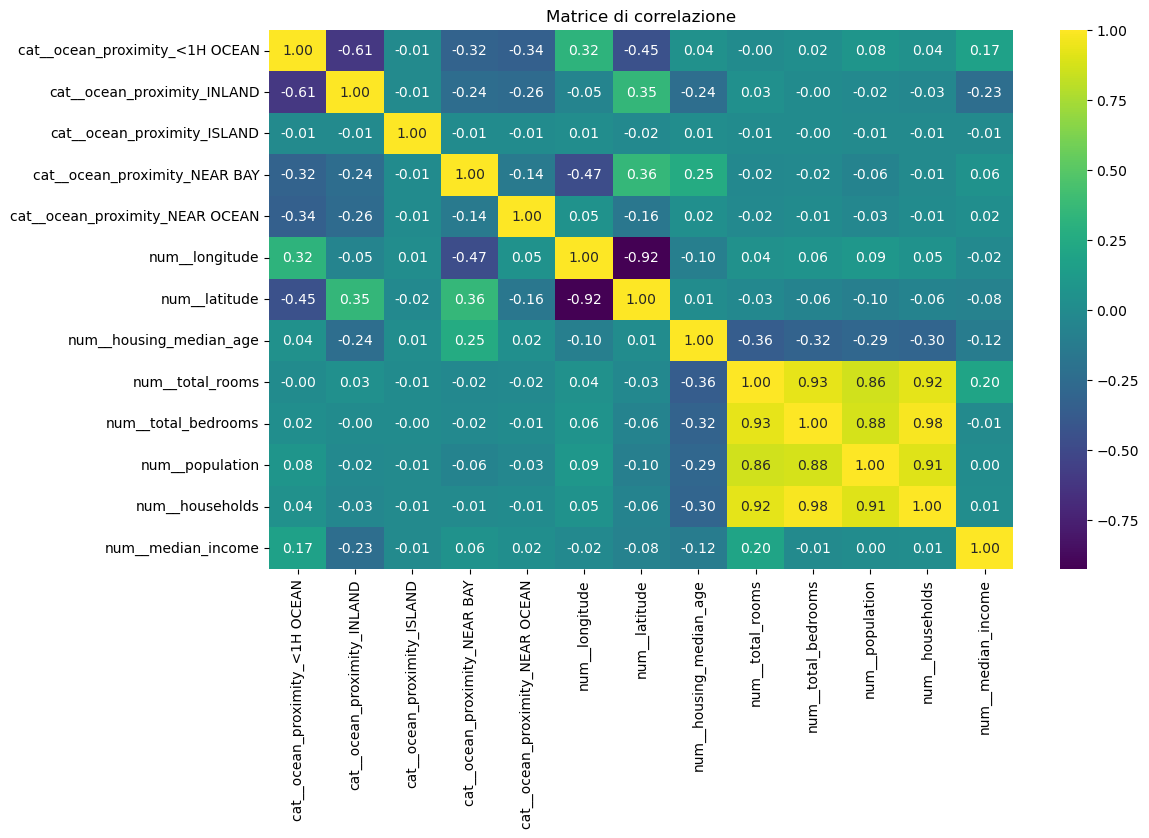

In [6]:
# Analisi Multicollinearità
import seaborn as sns
import matplotlib.pyplot as plt


corr = X_train_processed.corr()
plt.figure(figsize=(12,7))
sns.heatmap(corr, annot=True, cmap="viridis", fmt=".2f")
plt.title("Matrice di correlazione")
plt.show()

In [7]:
import numpy as np

upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
threshold = 0.80
pairs = upper.stack()
print(pairs[pairs.abs() > threshold])

num__longitude       num__latitude         -0.924485
num__total_rooms     num__total_bedrooms    0.930489
                     num__population        0.857936
                     num__households        0.920482
num__total_bedrooms  num__population        0.878932
                     num__households        0.980255
num__population      num__households        0.907452
dtype: float64


In [8]:
# Creiamo delle features come combinazioni lineari di queste, mantenendo solo un dato aggregato (households)

for dataset in [X_train_processed, X_test_processed,X_val_processed]:
    dataset["rooms_for_households"] = dataset["num__total_rooms"] / dataset["num__households"]
    dataset["population_for_households"] = dataset["num__population"] / dataset["num__households"]
    dataset["bedrooms_for_households"] = dataset["num__total_bedrooms"] / dataset["num__households"]

    dataset.drop(columns=["num__total_rooms","num__population","num__total_bedrooms","num__households"])

In [9]:
# Feature selection tramite tecnica embedded
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=3000, random_state=42, max_iter=1000)
select = SelectFromModel(estimator=lasso)

X_train_sel = select.fit_transform(X_train_processed, y_train)
X_val_sel = select.transform(X_val_processed)
X_test_sel = select.transform(X_test_processed)

selected_features = select.get_feature_names_out(input_features=X_train_processed.columns)
print(f"Features selezionate: {selected_features}")
print(f"Nuova shape: {X_train_sel.shape}")

Features selezionate: ['cat__ocean_proximity_INLAND' 'num__longitude' 'num__housing_median_age'
 'num__total_bedrooms' 'num__population' 'num__median_income'
 'rooms_for_households' 'population_for_households'
 'bedrooms_for_households']
Nuova shape: (16512, 9)


In [10]:
import sklearn.metrics
# Stampa tutti i nomi validi utilizzabili dentro scoring
print(sklearn.metrics.get_scorer_names())

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_macro', 'recall_micro', 'recall_samples'

In [11]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

param_grid_ridge = {
    "alpha" : [0.1, 1, 100, 1000]
}

ridge = Ridge(random_state=42)
cv = KFold(5, shuffle=True, random_state=42)
grid = GridSearchCV(ridge, param_grid_ridge, scoring="neg_mean_squared_error",cv=cv, n_jobs=-1)

grid.fit(X_train_sel, y_train)
best_ridge = grid.best_estimator_
best_params = grid.best_params_
best_score = grid.best_score_
y_pred_ridge_test = grid.predict(X_test_sel)
y_pred_ridge_train = grid.predict(X_train_sel)

from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error

r2_ridge_train = r2_score(y_train, y_pred_ridge_train)
r2_ridge_test = r2_score(y_test, y_pred_ridge_test)

print(f"R2 score Train: {r2_ridge_train:.4f}")
print(f"R2 score Test: {r2_ridge_test:.4f}")

mse_ridge_train = mean_squared_error(y_train, y_pred_ridge_train)
mse_ridge_test = mean_squared_error(y_test, y_pred_ridge_test)

print(f"MSE Train: {mse_ridge_train:.4f}")
print(f"MSE Test: {mse_ridge_test:.4f}")

rmse_ridge_train = root_mean_squared_error(y_train, y_pred_ridge_train)
rmse_ridge_test = root_mean_squared_error(y_test, y_pred_ridge_test)

print(f"RMSE Train: {rmse_ridge_train:.4f}")
print(f"RMSE Test: {rmse_ridge_test:.4f}")

print(f"Migliori parametri: {best_params}")
print(f"Miglior modello: {best_ridge}")
print(f"Miglior score medio in cv: {best_score:.4f}")

R2 score Train: 0.6338
R2 score Test: 0.6012
MSE Train: 4894694329.1407
MSE Test: 5286089355.3302
RMSE Train: 69962.0921
RMSE Test: 72705.4974
Migliori parametri: {'alpha': 1}
Miglior modello: Ridge(alpha=1, random_state=42)
Miglior score medio in cv: -4910543535.8166


In [12]:
# RandomForestRegressor
param_grid_rfc = {
    "n_estimators" : [50,100,150],
    "max_depth" : [10,20,None],
    "min_samples_split" : [2,5]
}

rfc = RandomForestRegressor(random_state=42)
grid_rfc = GridSearchCV(rfc, param_grid_rfc, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1)

grid_rfc.fit(X_train_sel,y_train)

best_rfc = grid_rfc.best_estimator_
best_params_rfc = grid_rfc.best_params_
best_score_rfc = grid_rfc.best_score_

y_pred_rfc_train = best_rfc.predict(X_train_sel)
y_pred_rfc_test = best_rfc.predict(X_test_sel)



r2_rfc_train = r2_score(y_train, y_pred_rfc_train)
r2_rfc_test = r2_score(y_test, y_pred_rfc_test)

print(f"R2 score Train: {r2_rfc_train:.4f}")
print(f"R2 score Test: {r2_rfc_test:.4f}")

mse_rfc_train = mean_squared_error(y_train, y_pred_rfc_train)
mse_rfc_test = mean_squared_error(y_test, y_pred_rfc_test)

print(f"MSE Train: {mse_rfc_train:.4f}")
print(f"MSE Test: {mse_rfc_test:.4f}")

rmse_rfc_train = root_mean_squared_error(y_train, y_pred_rfc_train)
rmse_rfc_test = root_mean_squared_error(y_test, y_pred_rfc_test)

print(f"RMSE Train: {rmse_rfc_train:.4f}")
print(f"RMSE Test: {rmse_rfc_test:.4f}")

print(f"Migliori parametri: {best_params_rfc}")
print(f"Miglior modello: {best_rfc}")
print(f"Miglior score medio in cv: {best_score_rfc:.4f}")

R2 score Train: 0.9691
R2 score Test: 0.7596
MSE Train: 413270333.3858
MSE Test: 3186543746.1789
RMSE Train: 20329.0515
RMSE Test: 56449.4796
Migliori parametri: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 150}
Miglior modello: RandomForestRegressor(n_estimators=150, random_state=42)
Miglior score medio in cv: -55549.1897


# Implementazione rete neurale densa 

Implementiamo una rete neurale densa con due layer nascosti (dropout pari a 0.2), Adam con Weight decay 1e4, learning rate linearmente decrescente a partire da 0.01, early stopping con patience di 10 epoche, min delta 0.001. Salvare il miglior modello rispetto al MSE. 

Epoch    1: 100%|██████████| 516/516 [00:02<00:00, 252.16it/s]


Train loss: 3826874412151.0698
Validation loss: 73901165350.7879
Test loss: 80121309479.5876 Accuracy:   0.00
Metrics:



Epoch    2: 100%|██████████| 516/516 [00:01<00:00, 348.63it/s]


Train loss: 67670257640.1860
Validation loss: 146181966816.9697
Test loss: 251486001215.3402 Accuracy:   0.00
Metrics:



Epoch    3: 100%|██████████| 516/516 [00:01<00:00, 328.80it/s]


...

Train loss: 7252480595.8450
Validation loss: 5446001954.9091
Test loss: 5761065010.1443 Accuracy:   0.00
Metrics:



Epoch   52: 100%|██████████| 516/516 [00:01<00:00, 337.70it/s]


Train loss: 7285889988.4651
Validation loss: 5615832052.3636
Test loss: 5890521411.2990 Accuracy:   0.00
Metrics:



Epoch   53: 100%|██████████| 516/516 [00:01<00:00, 349.55it/s]


Train loss: 7046671638.3256
Validation loss: 6061697885.0909
Test loss: 6268528641.3196 Accuracy:   0.00
Metrics:



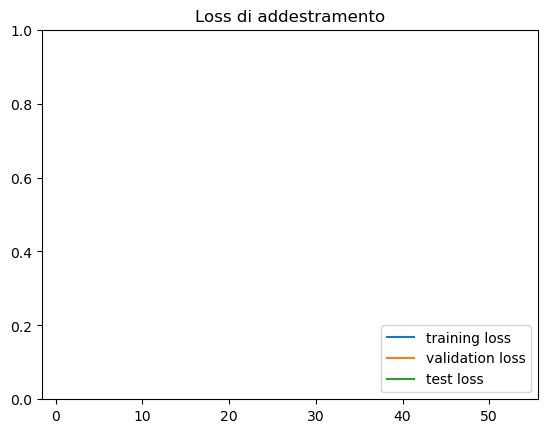

In [13]:
import torchnn as tnn
import torch
from torch.utils.data import Dataset, DataLoader
from torch import nn

class DataHouse(Dataset):
    def __init__(self, X,y):
        self.X = torch.tensor(np.array(X), dtype=torch.float32)
        self.y = torch.tensor(np.array(y), dtype=torch.float32).unsqueeze(1) #Per problemi di Regressione y deve essere di tipo float32
    def __getitem__(self, index):
        return self.X[index], self.y[index]
    def __len__(self):
        return len(self.X)

train_data = DataHouse(X_train_sel, y_train)
val_data = DataHouse(X_val_sel, y_val)
test_data = DataHouse(X_test_sel, y_test)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

input_dim = X_train_sel.shape[1]

class HouseNet(nn.Module):
    def __init__(self,input_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),

            nn.Linear(128,64),
            nn.Dropout(0.2),
            nn.ReLU(),

            nn.Linear(64,32),
            nn.Dropout(0.2),
            nn.ReLU(),

            nn.Linear(32,16),
            nn.Dropout(0.2),
            nn.ReLU(),

            nn.Linear(16,1)
        )
    def forward(self,x):
        return self.layers(x) 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HouseNet(input_dim).to(device)

import torch.optim as optim
from torch.optim import Adam

epochs=80
optimizer = Adam(model.parameters(), lr=0.01, weight_decay=1e-4) 
# viene richiesto che il learning rate decresca a partire da 0.01 => start_factor=1 => 0.01x1, infine si scende con end_factor = 0.1
scheduler = optim.lr_scheduler.LinearLR(optimizer=optimizer, start_factor=1, end_factor=0.1, total_iters=epochs)
early_stopping = tnn.EarlyStopping(patience=10, min_delta=0.001)
loss_fn = nn.MSELoss()

train_loss, validation_loss, test_loss, accuracy, test_metrics = tnn.train_test(
    model=model,
    optimizer=optimizer,
    device=device,
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    test_dataloader=test_loader,
    train_loss_fn=loss_fn,
    test_loss_fn=loss_fn,
    early_stopping=early_stopping,
    scheduler=scheduler,
    epochs=epochs,
    metrics=[],
    average="macro"
)

tnn.displayLosses(train_loss,test_loss, validation_loss)

tnn.save_model(model, optimizer, len(train_loss),train_loss,validation_loss, test_loss, accuracy, test_metrics, "best_model1.pt")

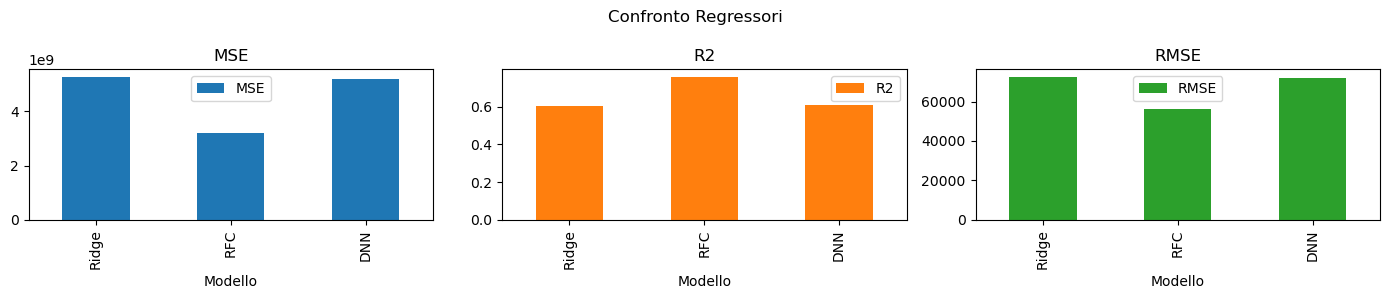

  Modello           MSE        R2          RMSE
0   Ridge  5.286089e+09  0.601239  72705.497422
1     RFC  3.186544e+09  0.759620  56449.479592
2     DNN  5.194662e+09  0.608136  72074.000951


In [18]:
# valutazione regressore neurale

def evaluate (model,device,test_loader):
    model.eval()

    nn_pred, nn_true = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:

            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            nn_true.extend(y_batch.cpu().numpy().flatten())
            nn_pred.extend(logits.cpu().numpy().flatten())

    return nn_true, nn_pred

nn_true, nn_pred = evaluate(model,device,test_loader)

nn_mse_test = mean_squared_error(nn_true,nn_pred)
nn_rmse_test = root_mean_squared_error(nn_true,nn_pred)
nn_r2_test = r2_score(nn_true, nn_pred)

res = pd.DataFrame({
    'Modello' : ["Ridge", "RFC", "DNN"],
    'MSE' : [mse_ridge_test, mse_rfc_test, nn_mse_test],
    'R2' : [r2_ridge_test, r2_rfc_test, nn_r2_test],
    'RMSE' : [rmse_ridge_test, rmse_rfc_test, nn_rmse_test] 
})

res.plot(kind='bar',subplots=True, sharex=True, title="Confronto Regressori", x='Modello', figsize=(14,3), layout=(1,3))
plt.tight_layout()
plt.show()
print(res)
        


